# Housing Price Prediction Using Linear Regression

This project predicts housing prices using the California Housing dataset.
We analyze housing features and build a Linear Regression model
to estimate house prices.

## Problem Statement

Housing prices vary depending on many factors such as
income level, house age, and number of rooms.

The goal of this project is to build a Linear Regression
model to predict housing prices.

## Dataset Description

Dataset Used: California Housing Dataset

Number of records: 20,640 houses

Features include:
- Median Income
- House Age
- Average Rooms
- Population
- Latitude
- Longitude

Target Variable:
House Price

Libraries Loaded Successfully

Dataset Loaded Successfully

First 5 Rows:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape: (20640, 9)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms 

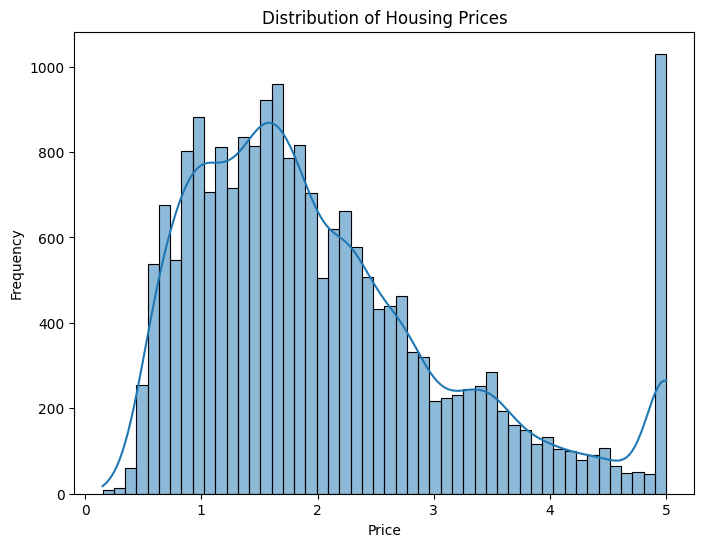

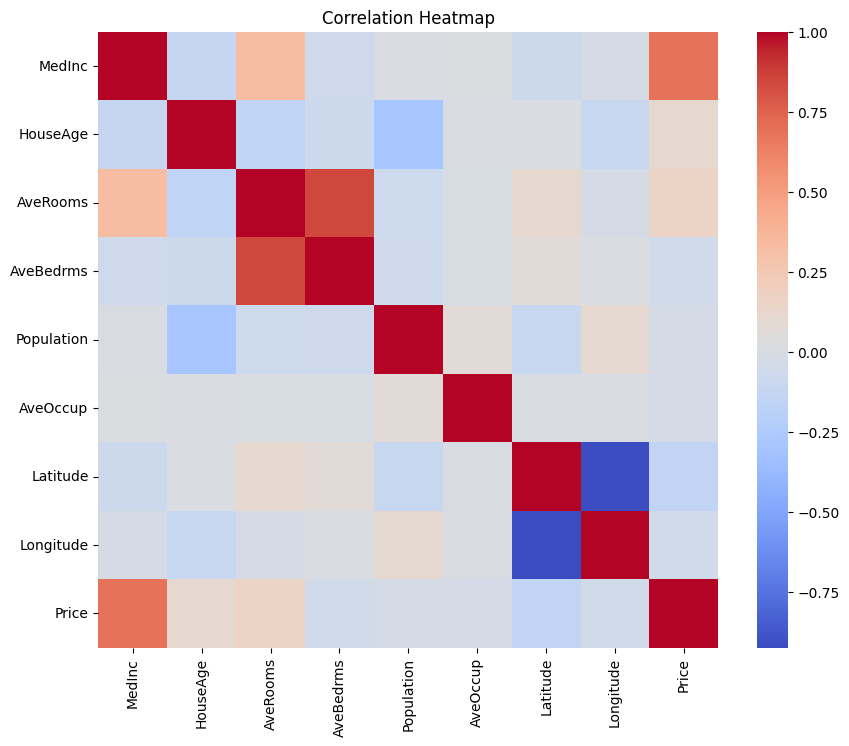

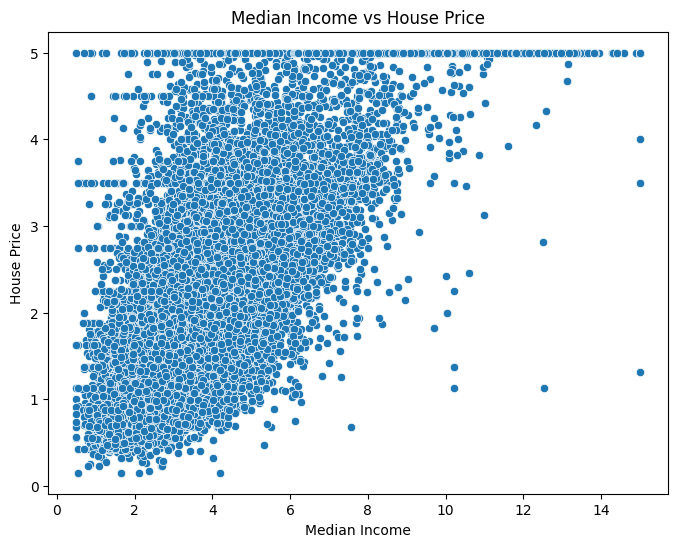

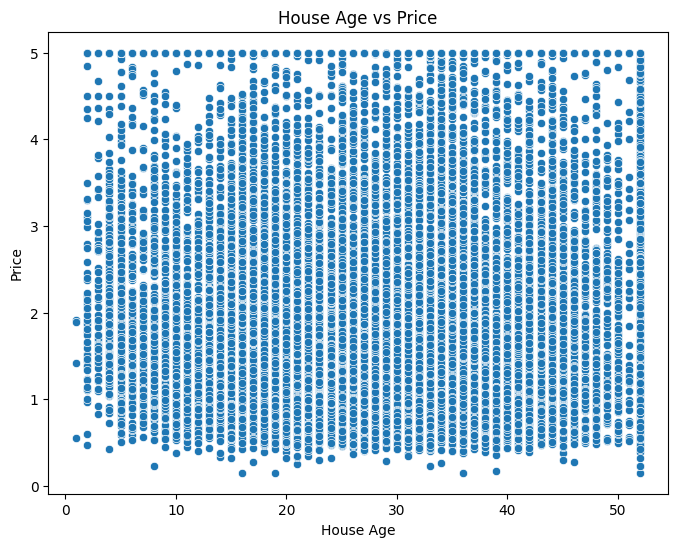

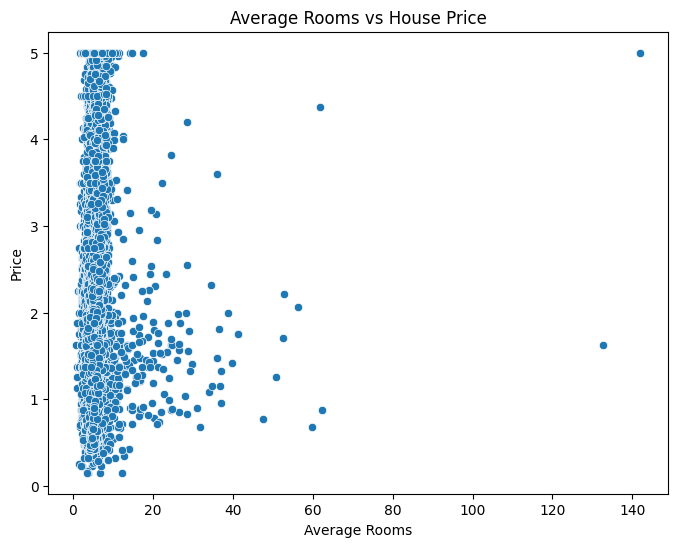


Selected Features:
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)

Feature Scaling Completed

Model Training Completed

Predictions Generated

Model Evaluation Results
Mean Squared Error: 0.5558915986952444
R2 Score: 0.5757877060324508


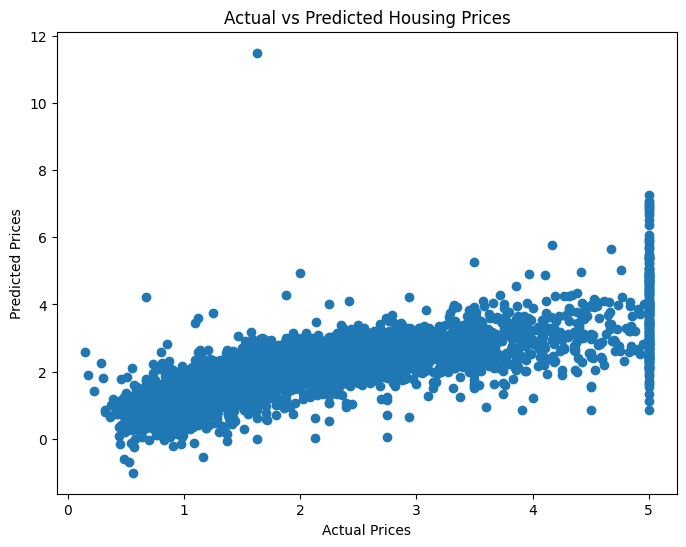


Feature Importance:

            Coefficient
MedInc         0.854383
HouseAge       0.122546
AveRooms      -0.294410
AveBedrms      0.339259
Population    -0.002308
AveOccup      -0.040829
Latitude      -0.896929
Longitude     -0.869842

Predicted Price for Sample House: [4.15194269]

Project Completed Successfully


In [1]:

# ================================
# 1 Import Required Libraries
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries Loaded Successfully\n")

# ================================
# 2 Load Dataset
# ================================

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Loaded Successfully\n")

# ================================
# 3 View Dataset
# ================================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:", df.shape)

# ================================
# 4 Dataset Information
# ================================

print("\nDataset Information:\n")
print(df.info())

# ================================
# 5 Check Missing Values
# ================================

print("\nMissing Values:\n")
print(df.isnull().sum())

# ================================
# 6 Statistical Summary
# ================================

print("\nStatistical Summary:\n")
print(df.describe())

# ================================
# 7 Exploratory Data Analysis
# ================================

# Price Distribution

plt.figure(figsize=(8,6))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# ================================
# Correlation Heatmap
# ================================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ================================
# Income vs Price
# ================================

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["MedInc"], y=df["Price"])
plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.show()

# ================================
# House Age vs Price
# ================================

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["HouseAge"], y=df["Price"])
plt.title("House Age vs Price")
plt.xlabel("House Age")
plt.ylabel("Price")
plt.show()

# ================================
# Rooms vs Price
# ================================

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["AveRooms"], y=df["Price"])
plt.title("Average Rooms vs House Price")
plt.xlabel("Average Rooms")
plt.ylabel("Price")
plt.show()

# ================================
# 8 Feature Selection
# ================================

X = df.drop("Price", axis=1)
y = df["Price"]

print("\nSelected Features:\n", X.columns)

# ================================
# 9 Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ================================
# 10 Feature Scaling
# ================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed")

# ================================
# 11 Train Linear Regression Model
# ================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")

# ================================
# 12 Predictions
# ================================

y_pred = model.predict(X_test)

print("\nPredictions Generated")

# ================================
# 13 Model Evaluation
# ================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Results")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# ================================
# 14 Actual vs Predicted Graph
# ================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

# ================================
# 15 Feature Importance
# ================================

coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=["Coefficient"]
)

print("\nFeature Importance:\n")
print(coefficients)

# ================================
# 16 Sample Prediction
# ================================

sample_house = X.iloc[0:1]

sample_scaled = scaler.transform(sample_house)

predicted_price = model.predict(sample_scaled)

print("\nPredicted Price for Sample House:", predicted_price)

# ================================
# 17 Project Completed
# ================================

print("\nProject Completed Successfully")

## Model Building

In this section we train a Linear Regression model
to predict housing prices using the selected features.

The dataset is divided into:
- Training data (80%)
- Testing data (20%)

## Model Evaluation

To evaluate the model performance we use:

Mean Squared Error (MSE)
R² Score

The R² score indicates how well the model explains
variation in housing prices.

## Conclusion

This project successfully built a housing price prediction
model using Linear Regression.

Key Findings:
- Median income strongly influences house prices.
- Houses in wealthier areas tend to have higher prices.
- The model achieved a reasonable R² score.

Future improvements could include using advanced models
such as Random Forest or Gradient Boosting to improve
prediction accuracy.